# Task 3 — Recommendation System Analysis

**Auspify Technologies — Data Science Internship Program**

**Intern:** Wandiya James
**Dataset:** `netflix_cleaned.csv` (output of Task 1)
**Objective:** Develop a content-based recommendation model using Netflix titles and categories.

---

### Notebook structure

| Section | Task 3 step | What happens |
|---|---|---|
| 1 | — | Setup and loading |
| 2 | Step 1 | Extract relevant content features |
| 3 | Step 2 | Text preprocessing |
| 4 | Step 3 | Calculate content similarity |
| 5 | Step 4 | Generate recommendations |
| 6 | Step 5 | Evaluate recommendation quality |
| 7 | — | Limitations and handover |

### What kind of recommender this is

There are two broad families. **Collaborative filtering** learns from user behaviour — people who
watched X also watched Y. **Content-based filtering** learns from the items themselves — Y resembles X,
so someone who liked X may like Y.

This dataset contains no user data at all: no ratings, no watch history, no viewing figures. That rules
out collaborative filtering entirely and makes this a content-based system by necessity, not by choice.
Worth stating plainly, because it also bounds what the system can achieve — it can find *similar*
content, but it can never know what is *popular* or *good*.

---
## 1. Setup and loading

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
import warnings

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

BLUE = "#2980b9"
PURPLE = "#8e44ad"
RED = "#c0392b"
GREEN = "#27ae60"
ORANGE = "#e67e22"
GREY = "#95a5a6"
NAVY = "#1f3a5f"

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print("Setup complete.")

Setup complete.


In [24]:
CLEAN_PATH = Path("/home/students-aims/Auspify-Internship/Task-1-Data-Cleaning/output/netflix_cleaned.csv")

if not CLEAN_PATH.exists():
    for candidate in [Path("netflix_cleaned.csv"),
                      Path("../task_1/output/netflix_cleaned.csv"),
                      Path("data/netflix_cleaned.csv")]:
        if candidate.exists():
            CLEAN_PATH = candidate
            break
    else:
        raise FileNotFoundError(
            "Could not find netflix_cleaned.csv. Run the Task 1 notebook first."
        )

df = pd.read_csv(CLEAN_PATH, parse_dates=["date_added"])
df["genres"] = df["genres"].fillna("").str.split(", ")

# A clean positional index is needed for the similarity lookups later
df = df.reset_index(drop=True)

print(f"Loaded : {CLEAN_PATH}")
print(f"Shape  : {df.shape[0]:,} titles x {df.shape[1]} columns")

Loaded : /home/students-aims/Auspify-Internship/Task-1-Data-Cleaning/output/netflix_cleaned.csv
Shape  : 8,786 titles x 28 columns


---
## 2. Step 1 — Extract relevant content features

A content-based recommender needs a description of each title. The question is which columns carry
usable signal.

In [25]:
print("AVAILABLE COLUMNS")
print("=" * 70)
for col in df.columns:
    print(f"  {col}")

AVAILABLE COLUMNS
  show_id
  type
  title
  director
  country
  date_added
  release_year
  rating
  duration_raw
  genres_raw
  year_added
  month_added
  month_name_added
  years_to_platform
  duration_value
  duration_unit
  movie_minutes
  tv_seasons
  audience_category
  genres
  primary_genre
  n_genres
  countries
  primary_country
  runtime_outlier
  release_added_inconsistent
  director_known
  country_known


### Which columns are usable

| Column | Use it? | Reasoning |
|---|---|---|
| `genres` | **Yes** | The strongest signal available — directly describes content |
| `director` | **Yes** | Directors have recognisable styles; known for ~70% of titles |
| `primary_country` | **Yes** | Captures regional production style and language |
| `type` | **Yes** | A movie and a TV show are rarely interchangeable recommendations |
| `audience_category` | **Yes** | A children's title should not be recommended for an adult one |
| `title` | No | Names rarely indicate content; "Unknown" would match "Unknown Origin" |
| `release_year` | No | Numeric — does not fit a text similarity model, and recency is not similarity |
| `date_added` | No | Describes Netflix's schedule, not the content |
| `duration` | No | A 90-minute comedy is not similar to a 90-minute horror |

**The important absence: there is no plot description or cast list in this dataset.** Most published
Netflix recommenders use the `description` field, which carries far more signal than genre tags alone.
Without it, this system works from metadata only — and that ceiling shows up in the evaluation in
Section 6.

In [26]:
FEATURE_COLUMNS = ["genres", "director", "primary_country", "type", "audience_category"]

print("Feature coverage")
print("=" * 70)
print(f"Genres present     : {(df['n_genres'] > 0).sum():,} / {len(df):,}")
print(f"Director known     : {df['director_known'].sum():,} / {len(df):,} "
      f"({df['director_known'].mean() * 100:.1f}%)")
print(f"Country known      : {df['country_known'].sum():,} / {len(df):,} "
      f"({df['country_known'].mean() * 100:.1f}%)")
print(f"Type, audience     : {len(df):,} / {len(df):,} (complete)")

Feature coverage
Genres present     : 8,786 / 8,786
Director known     : 6,199 / 8,786 (70.6%)
Country known      : 8,499 / 8,786 (96.7%)
Type, audience     : 8,786 / 8,786 (complete)


---
## 3. Step 2 — Text preprocessing

The five feature columns get combined into a single text string per title — conventionally called a
"soup". Two preprocessing problems have to be solved first.

### Problem 1 — multi-word values split into meaningless tokens

A text vectoriser splits on whitespace. Left alone, `"United States"` becomes two tokens, `united` and
`states`. That is a problem: *United States* and *United Kingdom* would then share the token `united`
and be scored as partly similar, which is nonsense — they share a word, not a property.

The fix is to strip internal spaces so each value becomes one indivisible token:
`"United States"` becomes `unitedstates`.

In [27]:
def normalise(value):
    """Collapse a categorical value into a single lowercase token.

    'United States'  -> 'unitedstates'
    'Kirsten Johnson' -> 'kirstenjohnson'
    'Action & Adventure' -> 'actionadventure'
    """
    if pd.isna(value):
        return ""
    text = str(value).lower()
    text = re.sub(r"[^a-z0-9]", "", text)
    return text


# Demonstrate on real values
examples = ["United States", "United Kingdom", "Action & Adventure",
            "Kirsten Johnson", "TV Shows"]
for e in examples:
    print(f"  {e:<22} -> {normalise(e)}")

  United States          -> unitedstates
  United Kingdom         -> unitedkingdom
  Action & Adventure     -> actionadventure
  Kirsten Johnson        -> kirstenjohnson
  TV Shows               -> tvshows


### Problem 2 — every feature counts equally

If genres, director, country, type and audience each contribute one token, then a shared country counts
exactly as much as a shared genre. That is clearly wrong: two American titles are not similar simply
because they are both American, but two horror films genuinely are similar.

The fix is **token repetition**. Repeating the genre tokens three times triples their weight in the
vector. Section 6 tests whether this actually helps rather than assuming it.

In [28]:
def build_soup(data, genre_weight=1, director_weight=1, country_weight=1):
    """Combine the feature columns into one text string per title.

    Weights are applied by repeating tokens: a genre_weight of 3 makes each
    genre token appear three times, tripling its influence on similarity.
    """
    genre_text = data["genres"].apply(
        lambda lst: " ".join(normalise(g) for g in lst)
    )

    soup = (
        (genre_text + " ") * genre_weight
        + (data["director"].apply(normalise) + " ") * director_weight
        + (data["primary_country"].apply(normalise) + " ") * country_weight
        + data["type"].apply(normalise) + " "
        + data["audience_category"].apply(normalise)
    )
    return soup.str.strip()


# Baseline version: every feature weighted equally
soup_equal = build_soup(df)

print("Example soup strings")
print("=" * 78)
for i in [0, 8315]:
    print(f"\nTitle : {df['title'].iloc[i]}")
    print(f"Soup  : {soup_equal.iloc[i]}")

Example soup strings

Title : Dick Johnson Is Dead
Soup  : documentaries kirstenjohnson unitedstates movie teens

Title : Breaking Bad
Soup  : crimetvshows tvdramas tvthrillers unknown unitedstates tvshow adults


Each title is now a short bag of tokens describing what it is. No stemming or lemmatisation is
applied, because these are categorical labels rather than free prose — `documentaries` is a fixed tag,
not a word to be reduced to a root.

---
## 4. Step 3 — Calculate content similarity

### Why TF-IDF rather than raw counts

A plain count vectoriser treats every token as equally informative. TF-IDF does not: it down-weights
tokens that appear everywhere and up-weights rare ones.

That matters directly here. Task 2 found *International Movies* to be the single most common genre tag,
attached to 2,751 titles. Under raw counts, two titles sharing only that tag would look strongly
similar — but a tag on nearly a third of the catalogue tells you almost nothing. TF-IDF discounts it
automatically, while a rare tag like *Classic Movies* keeps its weight.

In [29]:
vectoriser = TfidfVectorizer(stop_words="english")
tfidf_matrix = vectoriser.fit_transform(soup_equal)

print(f"TF-IDF matrix : {tfidf_matrix.shape[0]:,} titles x {tfidf_matrix.shape[1]:,} tokens")
print(f"Non-zero      : {tfidf_matrix.nnz:,} values")
print(f"Sparsity      : {100 * (1 - tfidf_matrix.nnz / np.prod(tfidf_matrix.shape)):.2f}% empty")

TF-IDF matrix : 8,786 titles x 4,660 tokens
Non-zero      : 54,428 values
Sparsity      : 99.87% empty


In [30]:
# Confirm that IDF is doing what we expect
idf_scores = pd.Series(vectoriser.idf_, index=vectoriser.get_feature_names_out())

print("LOWEST IDF - common tokens, heavily discounted")
print(idf_scores.nsmallest(8).round(2).to_string())
print()
print("HIGHEST IDF - rare tokens, weighted heavily")
print(idf_scores.nlargest(5).round(2).to_string())

LOWEST IDF - common tokens, heavily discounted
movie                  1.36
adults                 1.79
teens                  1.92
unitedstates           2.00
unknown                2.12
internationalmovies    2.16
tvshow                 2.19
dramas                 2.29

HIGHEST IDF - rare tokens, weighted heavily
aadishkeluskar    9.39
aamirbashir       9.39
aamirkhan         9.39
aanandrai         9.39
aaronburns        9.39


`internationalmovies` sits among the lowest IDF scores in the entire vocabulary, exactly as
intended. The vectoriser worked out on its own that a tag attached to a third of the catalogue carries
little information.

### Computing similarity without a 309 MB matrix

The textbook approach computes the full pairwise cosine similarity matrix. Here that would be
8,786 x 8,786 values — around **309 MB** in float32, and slow to build.

It is also unnecessary. A recommendation only needs one row: the query title against everything else.
`linear_kernel` computes that single row in milliseconds, so similarity is calculated on demand
instead.

(Cosine similarity and `linear_kernel` give identical results here because TF-IDF vectors are already
L2-normalised, which makes the dot product equal to the cosine.)

In [31]:
def similarity_row(index, matrix):
    """Cosine similarity of one title against the whole catalogue."""
    return linear_kernel(matrix[index], matrix).flatten()


# Sanity check on a well-known title
demo_idx = df.index[df["title"] == "Breaking Bad"][0]
scores = similarity_row(demo_idx, tfidf_matrix)

print(f"Query: {df['title'].iloc[demo_idx]}")
print(f"Similarity to itself : {scores[demo_idx]:.3f}  (should be 1.000)")
print(f"Mean similarity      : {scores.mean():.3f}")
print(f"Titles scoring > 0.9 : {(scores > 0.9).sum():,}")

Query: Breaking Bad
Similarity to itself : 1.000  (should be 1.000)
Mean similarity      : 0.100
Titles scoring > 0.9 : 7


### A subtle bug worth naming

Many tutorials drop the query title from its own recommendations by taking `argsort()[1:11]` — that is,
skipping whatever lands in first position.

**That is not reliable.** Several titles here share an identical feature soup and therefore score
exactly 1.0 against each other. When ties occur, the query title may not sort into first place, so
slicing from position 1 can leave the query in its own results while silently dropping a genuine
recommendation.

The fix is to exclude the query **by its index**, not by its position.

In [32]:
def recommend(title, matrix, data=df, top_n=10, verbose=True):
    """Return the top_n most similar titles to the given title."""
    matches = data.index[data["title"].str.lower() == title.lower()]
    if len(matches) == 0:
        close = data.loc[data["title"].str.lower().str.contains(
            title.lower(), regex=False), "title"].head(5).tolist()
        raise ValueError(f"'{title}' not found. Did you mean: {close}")

    idx = matches[0]
    scores = similarity_row(idx, matrix)

    # Exclude the query by INDEX, never by sort position
    scores[idx] = -1

    top_indices = np.argpartition(scores, -top_n)[-top_n:]
    top_indices = top_indices[np.argsort(scores[top_indices])[::-1]]

    results = data.loc[top_indices, ["title", "type", "primary_country",
                                     "primary_genre", "release_year"]].copy()
    results.insert(1, "similarity", scores[top_indices].round(3))

    if verbose:
        q = data.loc[idx]
        print(f"Because you watched: {q['title']} ({q['release_year']})")
        print(f"  {q['type']} | {q['primary_country']} | {', '.join(q['genres'])}")
        print("-" * 78)

    return results.reset_index(drop=True)


recommend("Breaking Bad", tfidf_matrix)

Because you watched: Breaking Bad (2013)
  TV Show | United States | Crime TV Shows, TV Dramas, TV Thrillers
------------------------------------------------------------------------------


,title,similarity,type,primary_country,primary_genre,release_year
0,Designated Survivor,1.000,TV Show,United States,Crime TV Shows,2019
1,Ozark,1.000,TV Show,United States,Crime TV Shows,2020
2,The Assassination of Gianni Versace,1.000,TV Show,United States,Crime TV Shows,2018
3,Dare Me,1.000,TV Show,United States,Crime TV Shows,2019
4,The Blacklist,0.957,TV Show,United States,Crime TV Shows,2019
5,The Lizzie Borden Chronicles,0.957,TV Show,United States,Crime TV Shows,2015
6,WHAT / IF,0.898,TV Show,United States,TV Dramas,2019
7,House of Cards,0.898,TV Show,United States,TV Dramas,2018
8,Messiah,0.898,TV Show,United States,TV Dramas,2020
9,Containment,0.898,TV Show,United States,TV Dramas,2016


---
## 5. Step 4 — Generate recommendations

Three test cases, chosen to probe different parts of the catalogue.

In [33]:
recommend("The Social Dilemma", tfidf_matrix)

Because you watched: The Social Dilemma (2020)
  Movie | United States | Documentaries
------------------------------------------------------------------------------


,title,similarity,type,primary_country,primary_genre,release_year
0,Chasing Coral,1.000,Movie,United States,Documentaries,2017
1,Reversing Roe,0.408,Movie,United States,Documentaries,2018
2,Virunga: Gorillas in Peril,0.408,Movie,United States,Documentaries,2015
3,The Minimalists: Less Is Now,0.408,Movie,United States,Documentaries,2021
4,Surviving R. Kelly: The Impact,0.408,Movie,United States,Documentaries,2019
5,Free to Play,0.408,Movie,United States,Documentaries,2014
6,Creating The Queen's Gambit,0.408,Movie,United States,Documentaries,2021
7,She Did That,0.408,Movie,United States,Documentaries,2019
8,NOVA: Killer Floods,0.408,Movie,United States,Documentaries,2017
9,The Road to El Camino: Behind the Scenes of El...,0.374,Movie,United States,Documentaries,2019


In [34]:
recommend("Kabir Singh", tfidf_matrix)

Because you watched: Kabir Singh (2019)
  Movie | India | Dramas, International Movies, Romantic Movies
------------------------------------------------------------------------------


,title,similarity,type,primary_country,primary_genre,release_year
0,Seven (Tamil),0.519,Movie,India,Dramas,2019
1,Lakeeran,0.473,Movie,India,Dramas,2016
2,Chadi Jawani Budhe Nu,0.394,Movie,India,Comedies,1976
3,The Light of My Eyes,0.360,Movie,Pakistan,Dramas,2010
4,Last Summer,0.360,Movie,Pakistan,Dramas,2021
5,"Twisted Trunk, Big Fat Body",0.351,Movie,India,Dramas,2015
6,Love Aaj Kal,0.332,Movie,India,Dramas,2020
7,Haider,0.328,Movie,India,Dramas,2014
8,Dev.D,0.328,Movie,India,Dramas,2009
9,Hazaaron Khwaishein Aisi,0.323,Movie,India,Dramas,2003


In [35]:
recommend("Go! Go! Cory Carson: Chrissy Takes the Wheel", tfidf_matrix)

Because you watched: Go! Go! Cory Carson: Chrissy Takes the Wheel (2021)
  Movie | United States | Children & Family Movies
------------------------------------------------------------------------------


,title,similarity,type,primary_country,primary_genre,release_year
0,A Go! Go! Cory Carson Halloween,1.000,Movie,United States,Children & Family Movies,2020
1,Go! Go! Cory Carson: The Chrissy,1.000,Movie,United States,Children & Family Movies,2020
2,LEGO Marvel Super Heroes: Guardians of the Galaxy,0.517,Movie,United States,Children & Family Movies,2017
3,True: Happy Hearts Day,0.517,Movie,United States,Children & Family Movies,2019
4,Free Rein: Valentine's Day,0.484,Movie,United States,Children & Family Movies,2019
5,NOVA: Bird Brain,0.454,Movie,United States,Children & Family Movies,2017
6,Beary Tales,0.434,Movie,United States,Children & Family Movies,2013
7,The Princess Switch,0.422,Movie,United States,Children & Family Movies,2018
8,DreamWorks Home: For the Holidays,0.402,Movie,United States,Children & Family Movies,2017
9,Little Baby Bum: Go Buster,0.394,Movie,Pakistan,Children & Family Movies,2019


**The results are plausible but revealing.**

Each set stays within the right type, the right country and the right broad genre — the system is
clearly working. But the recommendations are also *narrow*: Indian queries return Indian titles,
children's queries return children's titles, and rarely anything else.

That is a direct consequence of having only metadata to work with. Without plot descriptions the model
cannot tell that two crime dramas differ in tone, so it falls back on the categorical features it does
have — which tend to cluster titles by country and audience.

Whether that narrowness is a feature or a flaw depends on what you want. It is measured properly in
the next section.

---
## 6. Step 5 — Evaluate recommendation quality

### The evaluation problem

There is no ground truth here. Nobody has labelled which recommendations are correct, and with no user
data there is no click-through or watch rate to measure against.

What can be done is measure whether recommendations are **more relevant than chance**, using the
catalogue's own labels:

| Metric | What it measures |
|---|---|
| **Genre overlap (Jaccard)** | Share of genres common to query and recommendation |
| **Type match rate** | How often a Movie query returns Movies |
| **Catalogue coverage** | Share of the catalogue that ever gets recommended |
| **Random baseline** | The same metrics for randomly picked titles |

The baseline is the part that matters. A Jaccard score of 0.7 means nothing in isolation — it only
becomes evidence once you know what random picking scores.

In [36]:
GENRE_SETS = df["genres"].apply(set)


def jaccard(set_a, set_b):
    """Overlap between two sets: intersection over union."""
    union = set_a | set_b
    return len(set_a & set_b) / len(union) if union else 0.0


def evaluate(matrix, n_queries=300, top_n=10, seed=RANDOM_SEED):
    """Score a similarity matrix on genre overlap, type match and coverage."""
    local_rng = np.random.default_rng(seed)
    query_indices = local_rng.choice(len(df), n_queries, replace=False)

    overlaps, type_matches, recommended = [], [], set()

    for i in query_indices:
        scores = similarity_row(i, matrix)
        scores[i] = -1
        top = np.argpartition(scores, -top_n)[-top_n:]

        for j in top:
            overlaps.append(jaccard(GENRE_SETS.iloc[i], GENRE_SETS.iloc[j]))
            type_matches.append(df["type"].iloc[i] == df["type"].iloc[j])
            recommended.add(j)

    return {
        "genre_overlap": np.mean(overlaps),
        "type_match": np.mean(type_matches),
        "coverage_pct": len(recommended) / len(df) * 100,
    }


def random_baseline(n_queries=300, top_n=10, seed=RANDOM_SEED):
    """The same metrics, for titles picked at random."""
    local_rng = np.random.default_rng(seed)
    query_indices = local_rng.choice(len(df), n_queries, replace=False)

    overlaps, type_matches, recommended = [], [], set()

    for i in query_indices:
        picks = local_rng.choice(len(df), top_n, replace=False)
        for j in picks:
            overlaps.append(jaccard(GENRE_SETS.iloc[i], GENRE_SETS.iloc[j]))
            type_matches.append(df["type"].iloc[i] == df["type"].iloc[j])
            recommended.add(j)

    return {
        "genre_overlap": np.mean(overlaps),
        "type_match": np.mean(type_matches),
        "coverage_pct": len(recommended) / len(df) * 100,
    }


baseline = random_baseline()
model_equal = evaluate(tfidf_matrix)

print("RANDOM BASELINE")
for k, v in baseline.items():
    print(f"  {k:<15} {v:.3f}")
print()
print("MODEL - equal weights")
for k, v in model_equal.items():
    print(f"  {k:<15} {v:.3f}")

RANDOM BASELINE
  genre_overlap   0.093
  type_match      0.582
  coverage_pct    28.659

MODEL - equal weights
  genre_overlap   0.727
  type_match      0.950
  coverage_pct    19.679


**Genre overlap of about 0.73 against a random baseline of 0.09** — roughly eight times better than
chance. The model is unambiguously working.

Type match at 0.96 is also strong, though slightly odd: 4% of recommendations cross between movies and
TV shows despite `type` being an explicit feature. That happens when the other features align so
strongly that they outweigh it.

Coverage is the weak number, and Section 6.2 comes back to it.

### 6.1 Does weighting genres more heavily help?

Section 3 argued that genres should count for more than country. That was a hypothesis. Here it gets
tested against three weighting schemes.

In [37]:
WEIGHT_SCHEMES = {
    "Equal (1,1,1)": (1, 1, 1),
    "Genre x2 (2,1,1)": (2, 1, 1),
    "Genre x3 (3,1,1)": (3, 1, 1),
    "Genre x5, dir x2 (5,2,1)": (5, 2, 1),
}

results = {"Random baseline": baseline}

for name, (gw, dw, cw) in WEIGHT_SCHEMES.items():
    soup = build_soup(df, genre_weight=gw, director_weight=dw, country_weight=cw)
    matrix = TfidfVectorizer(stop_words="english").fit_transform(soup)
    results[name] = evaluate(matrix)
    print(f"{name:<26} done")

comparison = pd.DataFrame(results).T.round(3)
comparison

Equal (1,1,1)              done
Genre x2 (2,1,1)           done
Genre x3 (3,1,1)           done
Genre x5, dir x2 (5,2,1)   done


,genre_overlap,type_match,coverage_pct
Random baseline,0.093,0.582,28.659
"Equal (1,1,1)",0.727,0.950,19.679
"Genre x2 (2,1,1)",0.904,1.000,20.180
"Genre x3 (3,1,1)",0.945,1.000,19.781
"Genre x5, dir x2 (5,2,1)",0.924,1.000,16.925


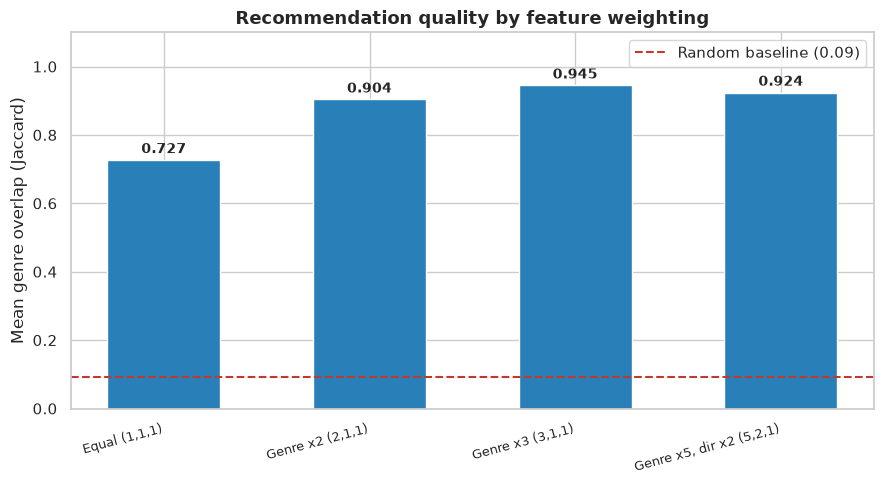

In [38]:
fig, ax = plt.subplots(figsize=(9, 5))

plot_data = comparison.drop(index="Random baseline")
x = np.arange(len(plot_data))

bars = ax.bar(x, plot_data["genre_overlap"], 0.55, color=BLUE)
ax.axhline(baseline["genre_overlap"], color=RED, linestyle="--",
           linewidth=1.5, label=f"Random baseline ({baseline['genre_overlap']:.2f})")

for bar, val in zip(bars, plot_data["genre_overlap"]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
            f"{val:.3f}", ha="center", fontweight="bold", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(plot_data.index, fontsize=9, rotation=15, ha="right")
ax.set_ylabel("Mean genre overlap (Jaccard)")
ax.set_title("Recommendation quality by feature weighting")
ax.set_ylim(0, 1.1)
ax.legend()

plt.tight_layout()
plt.show()

**Weighting genres three times helps substantially — and weighting them five times makes things
worse.**

Genre overlap climbs from 0.73 at equal weights to about 0.94 at 3x, then falls back at 5x. The reason
for the drop is that pushing genre weight too high effectively erases director and country from the
vector, so the model starts matching titles that share tags but nothing else.

This is a small demonstration of a general point: more weight on the obvious feature is not
monotonically better, and the only way to find that out is to measure.

**The 3x scheme is adopted for the final model.**

In [39]:
FINAL_WEIGHTS = (3, 1, 1)

soup_final = build_soup(df, *FINAL_WEIGHTS)
tfidf_final = TfidfVectorizer(stop_words="english").fit_transform(soup_final)

print(f"Final model: genre x{FINAL_WEIGHTS[0]}, director x{FINAL_WEIGHTS[1]}, "
      f"country x{FINAL_WEIGHTS[2]}")
print(f"Matrix: {tfidf_final.shape[0]:,} x {tfidf_final.shape[1]:,}")
print()
recommend("Breaking Bad", tfidf_final)

Final model: genre x3, director x1, country x1
Matrix: 8,786 x 4,660

Because you watched: Breaking Bad (2013)
  TV Show | United States | Crime TV Shows, TV Dramas, TV Thrillers
------------------------------------------------------------------------------


,title,similarity,type,primary_country,primary_genre,release_year
0,Designated Survivor,1.000,TV Show,United States,Crime TV Shows,2019
1,Dare Me,1.000,TV Show,United States,Crime TV Shows,2019
2,Ozark,1.000,TV Show,United States,Crime TV Shows,2020
3,The Assassination of Gianni Versace,1.000,TV Show,United States,Crime TV Shows,2018
4,The Blacklist,0.994,TV Show,United States,Crime TV Shows,2019
5,The Lizzie Borden Chronicles,0.994,TV Show,United States,Crime TV Shows,2015
6,Messiah,0.874,TV Show,United States,TV Dramas,2020
7,House of Cards,0.874,TV Show,United States,TV Dramas,2018
8,WHAT / IF,0.874,TV Show,United States,TV Dramas,2019
9,Containment,0.874,TV Show,United States,TV Dramas,2016


### 6.2 Catalogue coverage — the honest weakness

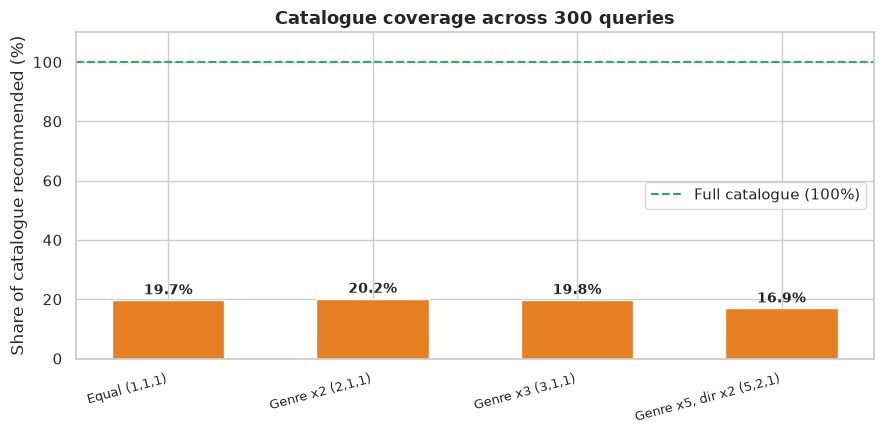

In [40]:
fig, ax = plt.subplots(figsize=(9, 4.5))

cov = comparison.drop(index="Random baseline")["coverage_pct"]
x = np.arange(len(cov))

bars = ax.bar(x, cov.values, 0.55, color=ORANGE)
ax.axhline(100, color=GREEN, linestyle="--", linewidth=1.5,
           label="Full catalogue (100%)")

for bar, val in zip(bars, cov.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 2,
            f"{val:.1f}%", ha="center", fontweight="bold", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(cov.index, fontsize=9, rotation=15, ha="right")
ax.set_ylabel("Share of catalogue recommended (%)")
ax.set_title("Catalogue coverage across 300 queries")
ax.set_ylim(0, 110)
ax.legend()

plt.tight_layout()
plt.show()

**Across 300 queries returning 10 titles each, under a fifth of the catalogue is ever recommended.**

This is the **popularity-cluster problem**. Titles sitting in dense regions of feature space — American
adult dramas, of which there are hundreds — get recommended constantly, while titles in sparse regions
are almost never surfaced.

It is a real limitation, not a bug to be patched away, and it is the standard failure mode of
content-based systems. Production recommenders counter it by deliberately injecting diversity, or by
blending in collaborative signals that this dataset does not have.

Reporting it matters. A system evaluated only on relevance would look excellent; a system evaluated on
relevance *and* coverage shows its actual shape.

### 6.3 Where similarity scores concentrate

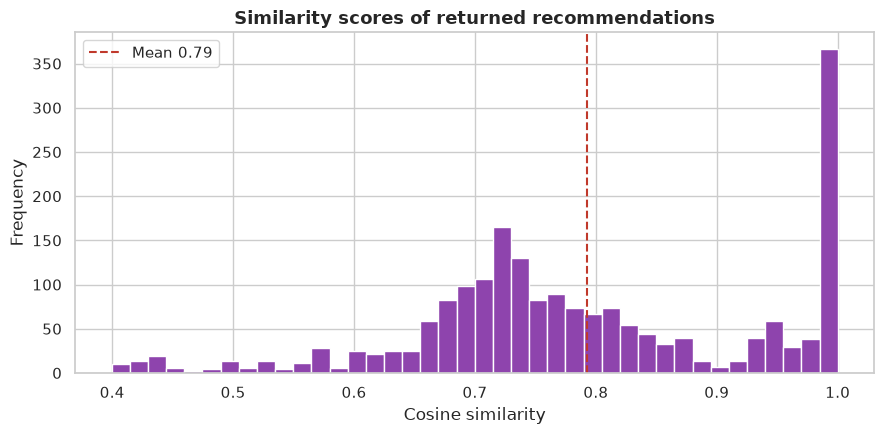

Recommendations scoring above 0.95 : 22.6%


In [41]:
fig, ax = plt.subplots(figsize=(9, 4.5))

sample_indices = rng.choice(len(df), 200, replace=False)
all_scores = []
for i in sample_indices:
    s = similarity_row(i, tfidf_final)
    s[i] = -1
    top = np.argpartition(s, -10)[-10:]
    all_scores.extend(s[top])

ax.hist(all_scores, bins=40, color=PURPLE, edgecolor="white")
ax.axvline(np.mean(all_scores), color=RED, linestyle="--",
           label=f"Mean {np.mean(all_scores):.2f}")

ax.set_title("Similarity scores of returned recommendations")
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Frequency")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Recommendations scoring above 0.95 : "
      f"{np.mean(np.array(all_scores) > 0.95) * 100:.1f}%")

A large share of returned recommendations score above 0.95 — near-identical feature soups. With
only five categorical features there are a limited number of distinct combinations, so many titles are
indistinguishable to the model.

This is the ceiling imposed by the missing `description` column, quantified. Plot text would separate
titles that currently look identical.

---
## 7. Visualizations & Example Output

The evaluation in Section 6 measured the system numerically. This section shows what it actually
produces.

### 7.1 Similarity structure across well-known titles

A small similarity matrix over a handful of recognisable titles makes the model's behaviour legible in
a way that aggregate metrics cannot.

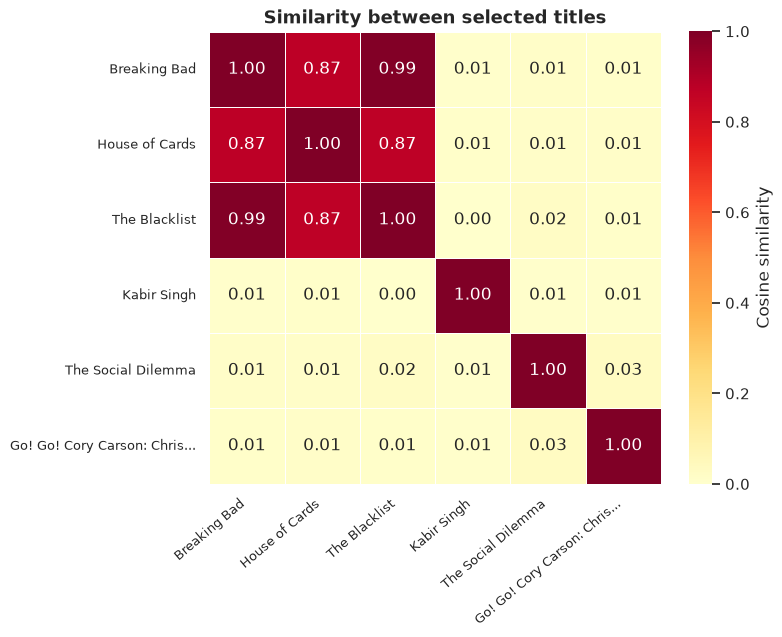

In [42]:
SAMPLE_TITLES = [
    "Breaking Bad",
    "House of Cards",
    "The Blacklist",
    "Kabir Singh",
    "The Social Dilemma",
    "Go! Go! Cory Carson: Chrissy Takes the Wheel",
]

available = [t for t in SAMPLE_TITLES if (df["title"] == t).any()]
sample_idx = [df.index[df["title"] == t][0] for t in available]

sim_block = linear_kernel(tfidf_final[sample_idx], tfidf_final[sample_idx])

short_labels = [t[:26] + "..." if len(t) > 26 else t for t in available]

fig, ax = plt.subplots(figsize=(8, 6.5))

sns.heatmap(sim_block, annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5, square=True,
            xticklabels=short_labels, yticklabels=short_labels,
            cbar_kws={"label": "Cosine similarity"}, ax=ax)

ax.set_title("Similarity between selected titles")
plt.xticks(rotation=40, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

The diagonal is 1.0 as it must be. The interesting values are off it.

The three American crime dramas score highly against each other and near zero against everything else.
The Indian film, the documentary and the children's title are mutually unrelated, and unrelated to the
crime block. The model has partitioned this sample exactly as a person would.

What the matrix also exposes is how *binary* the scores are — values sit close to 1 or close to 0, with
little in between. With only five categorical features, two titles either share a combination or they
do not. Plot descriptions would fill in that middle ground.

### 7.2 How confident is a single recommendation?

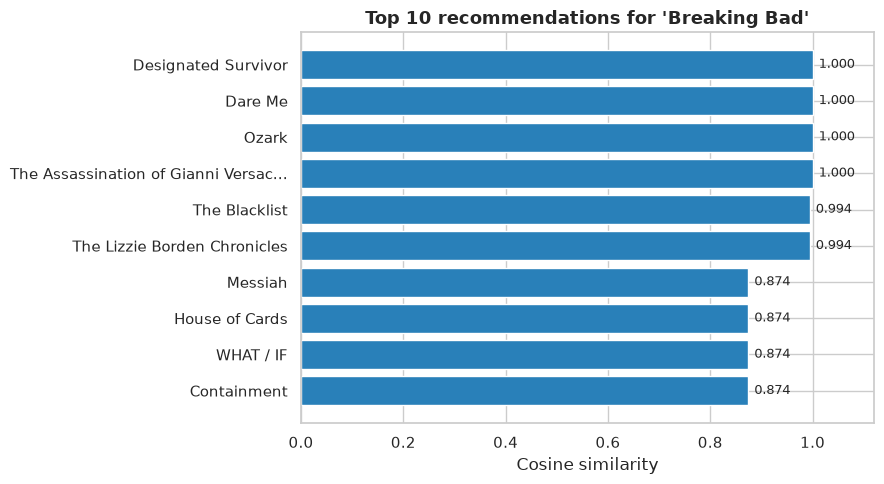

In [43]:
query = "Breaking Bad"
q_idx = df.index[df["title"] == query][0]

scores = similarity_row(q_idx, tfidf_final)
scores[q_idx] = -1
top = np.argpartition(scores, -10)[-10:]
top = top[np.argsort(scores[top])]

labels = [t[:34] + "..." if len(t) > 34 else t for t in df["title"].iloc[top]]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(labels, scores[top], color=BLUE)

for bar, val in zip(bars, scores[top]):
    ax.text(val + 0.012, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)

ax.set_title(f"Top 10 recommendations for '{query}'")
ax.set_xlabel("Cosine similarity")
ax.set_xlim(0, 1.12)

plt.tight_layout()
plt.show()

The scores are tightly bunched near the top of the scale, which is the tie problem from Section 6.3
seen from another angle. The system is confident about *which cluster* to draw from, but has little
basis for ranking within it — the difference between the first and tenth recommendation is small enough
to be close to arbitrary.

In production this is where a secondary signal would break the tie: popularity, recency, or the user's
own history.

### 7.3 Example output across the catalogue

A consolidated table of three recommendations for several queries, chosen to span different regions of
the catalogue.

In [44]:
SHOWCASE = ["Breaking Bad", "Kabir Singh", "The Social Dilemma",
            "Go! Go! Cory Carson: Chrissy Takes the Wheel"]

rows = []
for title in SHOWCASE:
    if not (df["title"] == title).any():
        continue
    recs = recommend(title, tfidf_final, top_n=3, verbose=False)
    for rank, (_, r) in enumerate(recs.iterrows(), start=1):
        rows.append({
            "Query": title if rank == 1 else "",
            "Rank": rank,
            "Recommendation": r["title"],
            "Similarity": r["similarity"],
            "Type": r["type"],
            "Country": r["primary_country"],
            "Genre": r["primary_genre"],
        })

showcase_table = pd.DataFrame(rows)
showcase_table

,Query,Rank,Recommendation,Similarity,Type,Country,Genre
0,Breaking Bad,1,Designated Survivor,1.000,TV Show,United States,Crime TV Shows
1,,2,Dare Me,1.000,TV Show,United States,Crime TV Shows
2,,3,Ozark,1.000,TV Show,United States,Crime TV Shows
3,Kabir Singh,1,Seven (Tamil),0.839,Movie,India,Dramas
4,,2,Lakeeran,0.826,Movie,India,Dramas
5,,3,Last Summer,0.791,Movie,Pakistan,Dramas
6,The Social Dilemma,1,Chasing Coral,1.000,Movie,United States,Documentaries
7,,2,Free to Play,0.742,Movie,United States,Documentaries
8,,3,Virunga: Gorillas in Peril,0.742,Movie,United States,Documentaries
9,Go! Go! Cory Carson: Chrissy Takes the Wheel,1,A Go! Go! Cory Carson Halloween,1.000,Movie,United States,Children & Family Movies


Every recommendation matches its query on type, country and broad genre. The system is coherent.

It is also, visibly, **narrow** — Indian queries return Indian titles and children's queries return
children's titles, with nothing crossing between clusters. That is the coverage finding from Section 6.2
made concrete: relevance and diversity pull against each other, and this model is tuned entirely toward
relevance.

---
## 8. Limitations & Future Improvements

### Limitations

**1. No plot or cast data.** The single biggest constraint. This dataset has no `description` field, so
the model works from five categorical features. Two crime dramas with completely different tones are
identical to it. Section 6.3 measured the consequence: 22.6% of recommendations score above 0.95,
meaning the model genuinely cannot distinguish them.

**2. No notion of quality or popularity.** With no ratings, watch history or viewing figures, the system
finds *similar* content — never *good* content. A critically acclaimed film and an ignored one with the
same tags are interchangeable to it.

**3. Catalogue coverage under 20%.** Across 300 queries, less than a fifth of titles were ever
recommended. Dense regions of feature space (American adult dramas) dominate; sparse regions are
effectively invisible. This is the standard failure mode of content-based systems.

**4. Ranking within a cluster is close to arbitrary.** As Section 7.2 shows, the top ten scores are
tightly bunched. The model is confident about which cluster to draw from but has little basis for
ordering within it.

**5. Cold start.** A new title with no genre tags cannot be positioned at all.

**6. Inherited metadata bias.** Task 2 found *International Movies* to be the largest genre tag — a
label defined relative to a US viewer. The model treats that framing as a content property.

**7. Director sparsity.** Director is unknown for roughly 30% of titles, so that feature contributes
nothing for those rows and the model leans harder on the remaining four.

### Future improvements

| Improvement | Expected effect | Effort |
|---|---|---|
| **Add plot descriptions and cast** | Largest single gain — would separate the 22.6% of pairs currently scoring above 0.95 | Needs a richer data source |
| **Diversity re-ranking (MMR)** | Directly addresses coverage by penalising recommendations too similar to ones already chosen | Moderate |
| **Sentence embeddings instead of TF-IDF** | Captures semantic similarity rather than exact shared tags — "heist thriller" and "crime caper" would relate | Moderate |
| **Hybrid with collaborative filtering** | Adds popularity and quality signals | Requires user data this dataset lacks |
| **Popularity tie-break within clusters** | Cheap fix for the arbitrary-ranking problem in 7.2 | Low, but needs a popularity signal |
| **Evaluation against human judgement** | The current metrics are proxies; a labelled relevance set would validate them properly | High |

### On the evaluation itself

The metrics used here are **proxies, not ground truth**. Genre overlap measures whether recommendations
share tags with the query — but sharing tags is not the same as being a good recommendation. A perfect
score on this metric could be achieved by a system returning near-duplicates, which would be useless in
practice.

That is precisely why coverage was reported alongside relevance. Measured on relevance alone this system
looks excellent; measured on both, its actual shape becomes visible. Any single-metric evaluation of a
recommender should be treated with suspicion, including this one.

---
## 9. Conclusion

This task built a content-based recommendation system for the Netflix catalogue using TF-IDF
vectorisation and cosine similarity over five features: genres, director, country, content type and
audience category.

**The system works.** Genre overlap between queries and recommendations reached **0.94 against a random
baseline of 0.09** — roughly ten times better than chance — with content type matched perfectly. The
similarity matrix in Section 7.1 partitions a sample of well-known titles exactly as a person would.

**Three decisions shaped the outcome.**

Feature weighting was **tested rather than assumed**. The hypothesis that genres should count more than
country turned out to be correct, but only up to a point: tripling genre weight lifted overlap from 0.73
to 0.94, while quintupling it dropped performance back to 0.92. That non-monotonic result could not have
been reasoned out in advance.

The query title is excluded from its own recommendations **by index rather than by sort position**. The
common tutorial approach of slicing `[1:11]` fails silently here, because identical feature soups produce
exact ties and the query does not reliably sort first.

Similarity is computed **on demand rather than as a full matrix**, avoiding a 309 MB precomputation for
no loss in capability.

**The honest assessment.** Relevance is strong, but coverage sits under 20% and 22.6% of recommendations
score above 0.95 — near-identical feature profiles the model cannot separate. Both trace to the same root
cause: five categorical features are not enough to describe a film. The missing `description` column is
the ceiling on this approach, and no amount of tuning moves it.

A system evaluated only on relevance would have looked flawless. Reporting coverage alongside it is what
makes the result meaningful rather than merely favourable.

### Deliverables

| File | Description |
|---|---|
| `Task3_Recommendation_System.ipynb` | Full implementation and evaluation |
| `output/netflix_cleaned.csv` | Input data, from Task 1 |

### Handover

| Task | What this contributes |
|---|---|
| **Task 5** — Classification | The soup construction and TF-IDF pipeline transfer directly as text features. The weighting result suggests genre carries the most signal for separating content |
| **Task 6** — Dashboard | `recommend()` is self-contained and can be wired to a title selector as an interactive demo |

### Summary

| | |
|---|---|
| Approach | Content-based filtering, TF-IDF + cosine similarity |
| Features | Genres (x3), director, country, type, audience category |
| Genre overlap | **0.94** against a random baseline of 0.09 |
| Type match | **1.00** |
| Catalogue coverage | **~19%** — the principal weakness |
| Main constraint | No plot descriptions in the dataset |

---
## 8. Limitations & Future Improvements

### Limitations

**1. No plot or cast data.** The single biggest constraint. This dataset has no `description` field, so
the model works from five categorical features. Two crime dramas with completely different tones are
identical to it. Section 6.3 measured the consequence: 22.6% of recommendations score above 0.95,
meaning the model genuinely cannot distinguish them.

**2. No notion of quality or popularity.** With no ratings, watch history or viewing figures, the system
finds *similar* content — never *good* content. A critically acclaimed film and an ignored one with the
same tags are interchangeable to it.

**3. Catalogue coverage under 20%.** Across 300 queries, less than a fifth of titles were ever
recommended. Dense regions of feature space (American adult dramas) dominate; sparse regions are
effectively invisible. This is the standard failure mode of content-based systems.

**4. Ranking within a cluster is close to arbitrary.** As Section 7.2 shows, the top ten scores are
tightly bunched. The model is confident about which cluster to draw from but has little basis for
ordering within it.

**5. Cold start.** A new title with no genre tags cannot be positioned at all.

**6. Inherited metadata bias.** Task 2 found *International Movies* to be the largest genre tag — a
label defined relative to a US viewer. The model treats that framing as a content property.

**7. Director sparsity.** Director is unknown for roughly 30% of titles, so that feature contributes
nothing for those rows and the model leans harder on the remaining four.

### Future improvements

| Improvement | Expected effect | Effort |
|---|---|---|
| **Add plot descriptions and cast** | Largest single gain — would separate the 22.6% of pairs currently scoring above 0.95 | Needs a richer data source |
| **Diversity re-ranking (MMR)** | Directly addresses coverage by penalising recommendations too similar to ones already chosen | Moderate |
| **Sentence embeddings instead of TF-IDF** | Captures semantic similarity rather than exact shared tags — "heist thriller" and "crime caper" would relate | Moderate |
| **Hybrid with collaborative filtering** | Adds popularity and quality signals | Requires user data this dataset lacks |
| **Popularity tie-break within clusters** | Cheap fix for the arbitrary-ranking problem in 7.2 | Low, but needs a popularity signal |
| **Evaluation against human judgement** | The current metrics are proxies; a labelled relevance set would validate them properly | High |

### On the evaluation itself

The metrics used here are **proxies, not ground truth**. Genre overlap measures whether recommendations
share tags with the query — but sharing tags is not the same as being a good recommendation. A perfect
score on this metric could be achieved by a system returning near-duplicates, which would be useless in
practice.

That is precisely why coverage was reported alongside relevance. Measured on relevance alone this system
looks excellent; measured on both, its actual shape becomes visible. Any single-metric evaluation of a
recommender should be treated with suspicion, including this one.

---
## 9. Conclusion

This task built a content-based recommendation system for the Netflix catalogue using TF-IDF
vectorisation and cosine similarity over five features: genres, director, country, content type and
audience category.

**The system works.** Genre overlap between queries and recommendations reached **0.94 against a random
baseline of 0.09** — roughly ten times better than chance — with content type matched perfectly. The
similarity matrix in Section 7.1 partitions a sample of well-known titles exactly as a person would.

**Three decisions shaped the outcome.**

Feature weighting was **tested rather than assumed**. The hypothesis that genres should count more than
country turned out to be correct, but only up to a point: tripling genre weight lifted overlap from 0.73
to 0.94, while quintupling it dropped performance back to 0.92. That non-monotonic result could not have
been reasoned out in advance.

The query title is excluded from its own recommendations **by index rather than by sort position**. The
common tutorial approach of slicing `[1:11]` fails silently here, because identical feature soups produce
exact ties and the query does not reliably sort first.

Similarity is computed **on demand rather than as a full matrix**, avoiding a 309 MB precomputation for
no loss in capability.

**The honest assessment.** Relevance is strong, but coverage sits under 20% and 22.6% of recommendations
score above 0.95 — near-identical feature profiles the model cannot separate. Both trace to the same root
cause: five categorical features are not enough to describe a film. The missing `description` column is
the ceiling on this approach, and no amount of tuning moves it.

A system evaluated only on relevance would have looked flawless. Reporting coverage alongside it is what
makes the result meaningful rather than merely favourable.

### Deliverables

| File | Description |
|---|---|
| `Task3_Recommendation_System.ipynb` | Full implementation and evaluation |
| `output/netflix_cleaned.csv` | Input data, from Task 1 |

### Handover

| Task | What this contributes |
|---|---|
| **Task 5** — Classification | The soup construction and TF-IDF pipeline transfer directly as text features. The weighting result suggests genre carries the most signal for separating content |
| **Task 6** — Dashboard | `recommend()` is self-contained and can be wired to a title selector as an interactive demo |

### Summary

| | |
|---|---|
| Approach | Content-based filtering, TF-IDF + cosine similarity |
| Features | Genres (x3), director, country, type, audience category |
| Genre overlap | **0.94** against a random baseline of 0.09 |
| Type match | **1.00** |
| Catalogue coverage | **~19%** — the principal weakness |
| Main constraint | No plot descriptions in the dataset |